# 3I - Interpretacao integrada da Fase 3

**Pergunta especifica.** Depois de 3A-3H, qual e a leitura fisica defensavel do Nino 3.4, o que entra no parecer, como comparar P90/P95 e como ler a janela 2026?

**Objetivo.** Consolidar evidencias, limites e proximos gates em uma saida interpretativa unica, rastreavel a tabelas e figuras ja materializadas.

**Justificativa.** A Fase 3 produziu muitas tabelas. O 3I existe para evitar interpretacao solta: ele cruza cobertura, eventos, P90/P95, rigor estatistico, estabilidade, DHW/Kelvin, genese e estado atual.

**Metodologia.** Le somente `data/processed/parquet/features` e `data/processed/parquet/statistics`; nao recalcula dado primario. Gera tabelas executivas, uma figura-sintese e um Markdown interpretativo para o parecer.

**Saidas.** `phase3I_conclusoes_decisao.csv`, `phase3I_picos_p90_p95_comparacao.csv`, `phase3I_estado_2026.csv`, `phase3I_interpretacao_integrada.md`, `phase3I_sintese_parecer.png`.


In [1]:
import sys, numpy as np, pandas as pd, matplotlib.pyplot as plt
from pathlib import Path
sys.path.insert(0, '.')
import fase3_utils as u

weekly = pd.read_csv(u.FEAT / 'phase3_indices_semanais.csv', parse_dates=['week_ending_sunday']).set_index('week_ending_sunday')
monthly = pd.read_csv(u.FEAT / 'nino34_monthly_oisst.csv', parse_dates=['time'])
daily = pd.read_csv(u.FEAT / 'nino34_daily_oisst.csv', parse_dates=['time'])
events = u.load_events()
p90 = u.load_p90_peaks(); p95 = u.load_p95_peaks()
rank3d = pd.read_csv(u.STATS / 'phase3D_ranking_significativo.csv')
est = pd.read_csv(u.STATS / 'phase3E_estabilidade.csv')
dhw_red = pd.read_csv(u.STATS / 'phase3F_dhw_redundancia.csv')
dhw_scale = pd.read_csv(u.STATS / 'phase3G_escalonamento.csv')
gen_sep = pd.read_csv(u.STATS / 'phase3H_separacao_genese.csv')
print('Entradas carregadas:', len(weekly), 'semanas;', len(events), 'eventos;', len(p90), 'picos P90;', len(p95), 'picos P95')


Entradas carregadas: 2375 semanas; 12 eventos; 11 picos P90; 6 picos P95


In [2]:
# Tabela 3I-1: o que entra no parecer e com qual linguagem
stable = est[est['estavel']].copy()
unstable = est[~est['estavel']].copy()
rows = []
for _, r in stable.iterrows():
    var = r['variavel']
    role = 'precursor estavel' if r['lag_semanas'] > 1 else 'estado simultaneo/curto prazo'
    if var in ['d20_m','ohc_0_300','ohc_0_700','ssh_m','tilt_m','wwv']:
        bloco = 'recarga/subsuperficie'
    elif var.startswith('dhw'):
        bloco = 'calor acumulado'
    elif var.startswith('atl'):
        bloco = 'controle atlantico'
    elif var.startswith('tau'):
        bloco = 'vento/acoplamento'
    else:
        bloco = 'outro'
    rows.append({'evidencia': var, 'bloco': bloco, 'lag_semanas': int(r['lag_semanas']),
                 'status': role, 'uso_no_parecer': 'entra',
                 'frase_recomendada': f"{var} sobrevive a 3D e 3E; interpretar como {role} do bloco {bloco}."})
for _, r in unstable.iterrows():
    rows.append({'evidencia': r['variavel'], 'bloco': 'regime_dependente', 'lag_semanas': int(r['lag_semanas']),
                 'status': 'instavel entre subperiodos', 'uso_no_parecer': 'entra como limite/ressalva',
                 'frase_recomendada': f"{r['variavel']} e significativo no periodo completo, mas nao e estavel nos dois regimes; reportar como limite, nao como lei geral."})
# regra extra do DHW por parcial
for metric, g in dhw_red.groupby('metrica_dhw'):
    sig = g[g['p_efetivo_parcial'] < 0.05]
    if sig.empty:
        frase = f"{metric}: parcial contra SSTA futura nao sobrevive; usar apenas como severidade/sensibilidade."
        uso = 'sensibilidade'
    else:
        hs = ', '.join(str(int(x)) for x in sig['horizonte_semanas'])
        frase = f"{metric}: parcial significativa apenas no curto prazo ({hs} semanas); usar como memoria curta/severidade, nao precursor longo."
        uso = 'curto prazo/severidade'
    rows.append({'evidencia': metric, 'bloco': 'DHW', 'lag_semanas': np.nan, 'status': 'regra extra 3F',
                 'uso_no_parecer': uso, 'frase_recomendada': frase})
concl = pd.DataFrame(rows)
u.save_table(concl, 'phase3I_conclusoes_decisao.csv', index=False)
concl


[tabela] data\processed\parquet\statistics\phase3I_conclusoes_decisao.csv


,evidencia,bloco,lag_semanas,status,uso_no_parecer,frase_recomendada
0,tilt_m,recarga/subsuperficie,0.0,estado simultaneo/curto prazo,entra,tilt_m sobrevive a 3D e 3E; interpretar como e...
1,ssh_m,recarga/subsuperficie,6.0,precursor estavel,entra,ssh_m sobrevive a 3D e 3E; interpretar como pr...
2,ohc_0_300,recarga/subsuperficie,6.0,precursor estavel,entra,ohc_0_300 sobrevive a 3D e 3E; interpretar com...
3,ohc_0_700,recarga/subsuperficie,6.0,precursor estavel,entra,ohc_0_700 sobrevive a 3D e 3E; interpretar com...
4,d20_m,recarga/subsuperficie,15.0,precursor estavel,entra,d20_m sobrevive a 3D e 3E; interpretar como pr...
5,tau_x_proxy_nino34_pa,vento/acoplamento,1.0,estado simultaneo/curto prazo,entra,tau_x_proxy_nino34_pa sobrevive a 3D e 3E; int...
6,atl4_ssta,controle atlantico,25.0,precursor estavel,entra,atl4_ssta sobrevive a 3D e 3E; interpretar com...
7,dhw_12w,regime_dependente,0.0,instavel entre subperiodos,entra como limite/ressalva,"dhw_12w e significativo no periodo completo, m..."
8,wwv,regime_dependente,20.0,instavel entre subperiodos,entra como limite/ressalva,"wwv e significativo no periodo completo, mas n..."
9,dhw_12w,DHW,NaN,regra extra 3F,curto prazo/severidade,dhw_12w: parcial significativa apenas no curto...


In [3]:
# Tabela 3I-2: picos P90 e P95 com metricas comparaveis de recarga e DHW

def nearest_week(ts):
    return weekly.index[weekly.index.get_indexer([pd.Timestamp(ts)], method='nearest')[0]]

def val_at(col, ts, lag=0):
    idx = nearest_week(ts) - pd.Timedelta(weeks=lag)
    return float(weekly[col].asof(idx))

def peak_table(peaks, label):
    rows = []
    for _, p in peaks.iterrows():
        peak = pd.Timestamp(p['peak_time'])
        rows.append({
            'metrica_percentil': label,
            'limiar_c': round(float(p['percentile_threshold_c']), 3),
            'event_id': p['event_id'],
            'event_start': p['event_start'],
            'event_end': p['event_end'],
            'duration_months': int(p['duration_months']),
            'peak_time': peak,
            'peak_rank': int(p['peak_rank']),
            'peak_nino34_anom_c': round(float(p['peak_nino34_anom_c']), 3),
            'd20_15w_antes_m': round(val_at('d20_m', peak, lag=15), 3),
            'ohc300_6w_antes_j_m2': round(val_at('ohc_0_300', peak, lag=6), 1),
            'ssh_6w_antes_m': round(val_at('ssh_m', peak, lag=6), 4),
            'wwv_20w_antes_m3': round(val_at('wwv', peak, lag=20), 1),
            'dhw_12w_no_pico_cweeks': round(val_at('dhw_12w', peak), 3),
            'dhw_26w_p90_no_pico_cweeks': round(val_at('dhw_26w_p90', peak), 3),
        })
    return pd.DataFrame(rows)
peaks_cmp = pd.concat([peak_table(p90, 'P90'), peak_table(p95, 'P95')], ignore_index=True)
u.save_table(peaks_cmp, 'phase3I_picos_p90_p95_comparacao.csv', index=False)
peaks_cmp.sort_values(['metrica_percentil','peak_rank'])


[tabela] data\processed\parquet\statistics\phase3I_picos_p90_p95_comparacao.csv


,metrica_percentil,limiar_c,event_id,event_start,event_end,duration_months,peak_time,peak_rank,peak_nino34_anom_c,d20_15w_antes_m,ohc300_6w_antes_j_m2,ssh_6w_antes_m,wwv_20w_antes_m3,dhw_12w_no_pico_cweeks,dhw_26w_p90_no_pico_cweeks
8,P90,0.992,nino34_oisst_p90_peak_2015_11,2015-06-01,2016-03-01,10,2015-11-01,1,2.789,141.382,2.523145e+10,0.6364,2.543063e+15,11.384,12.186
0,P90,0.992,nino34_oisst_p90_peak_1982_12,1982-09-01,1983-03-01,7,1982-12-01,2,2.280,144.999,2.468324e+10,0.5415,2.308274e+15,7.751,7.202
4,P90,0.992,nino34_oisst_p90_peak_1997_11,1997-07-01,1998-03-01,9,1997-11-01,3,2.174,131.693,2.571678e+10,0.6281,2.623960e+15,10.956,11.805
10,P90,0.992,nino34_oisst_p90_peak_2023_12,2023-07-01,2024-03-01,9,2023-12-01,4,2.007,138.683,2.506107e+10,0.6057,2.608831e+15,8.492,9.481
2,P90,0.992,nino34_oisst_p90_peak_1992_01,1991-12-01,1992-04-01,5,1992-01-01,5,1.736,138.433,2.431217e+10,0.4959,2.223186e+15,2.160,1.835
7,P90,0.992,nino34_oisst_p90_peak_2009_12,2009-11-01,2010-03-01,5,2009-12-01,6,1.719,131.654,2.421068e+10,0.5243,2.488365e+15,2.132,1.797
1,P90,0.992,nino34_oisst_p90_peak_1987_09,1987-07-01,1987-09-01,3,1987-09-01,7,1.340,112.783,2.283865e+10,0.4450,2.114075e+15,1.493,1.086
5,P90,0.992,nino34_oisst_p90_peak_2002_12,2002-10-01,2002-12-01,3,2002-12-01,8,1.335,140.899,2.506596e+10,0.5773,2.465787e+15,1.631,1.162
3,P90,0.992,nino34_oisst_p90_peak_1994_12,1994-12-01,1994-12-01,1,1994-12-01,9,1.192,134.494,2.391146e+10,0.5000,2.259122e+15,0.258,0.175
6,P90,0.992,nino34_oisst_p90_peak_2006_12,2006-12-01,2006-12-01,1,2006-12-01,10,1.128,136.968,2.391653e+10,0.4949,2.446581e+15,0.041,0.002


In [4]:
# Tabela 3I-3: leitura da janela 2026
last_daily = daily.sort_values('time').iloc[-1]
complete_months = monthly[monthly['month_complete'].astype(bool)].copy()
last_complete = complete_months.sort_values('time').iloc[-1]
last_month = monthly.sort_values('time').iloc[-1]
p90_thr = float(p90['percentile_threshold_c'].iloc[0])
p95_thr = float(p95['percentile_threshold_c'].iloc[0])
state = pd.DataFrame([{
    'ultimo_dia_oisst': last_daily['time'].date().isoformat(),
    'ssta_diaria_ultima_c': round(float(last_daily['nino34_ssta']), 3),
    'ultimo_mes_completo': last_complete['time'].date().isoformat(),
    'ssta_mes_completo_c': round(float(last_complete['nino34_ssta_c']), 3),
    'ultimo_mes_na_tabela': last_month['time'].date().isoformat(),
    'ultimo_mes_completo_bool': bool(last_month['month_complete']),
    'ssta_ultimo_mes_c': round(float(last_month['nino34_ssta_c']), 3),
    'limiar_p90_mensal_c': round(p90_thr, 3),
    'limiar_p95_mensal_c': round(p95_thr, 3),
    'leitura_2026': 'aquecimento em curso; junho/2026 parcial nao fecha evento nem pico historico ate completar o mes e a duracao minima',
}])
u.save_table(state, 'phase3I_estado_2026.csv', index=False)
state


[tabela] data\processed\parquet\statistics\phase3I_estado_2026.csv


,ultimo_dia_oisst,ssta_diaria_ultima_c,ultimo_mes_completo,ssta_mes_completo_c,ultimo_mes_na_tabela,ultimo_mes_completo_bool,ssta_ultimo_mes_c,limiar_p90_mensal_c,limiar_p95_mensal_c,leitura_2026
0,2026-06-09,1.435,2026-05-01,0.944,2026-06-01,False,1.364,0.992,1.582,aquecimento em curso; junho/2026 parcial nao f...


[figura] data\processed\figures\fase3\phase3I_sintese_parecer.png


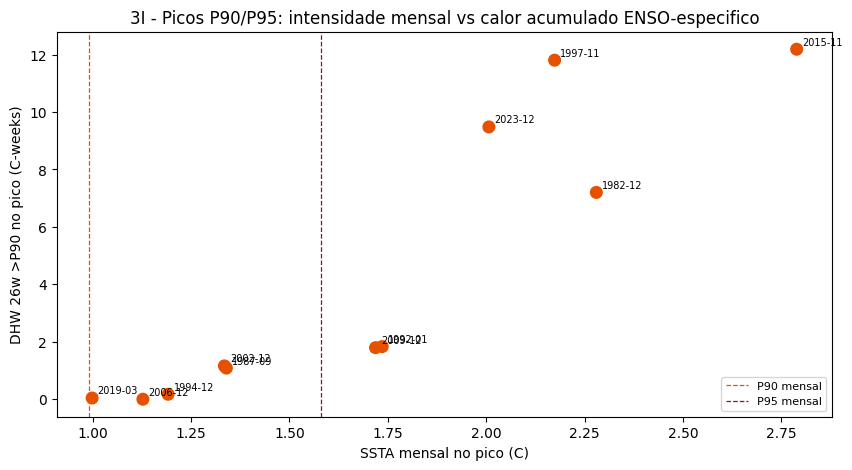

In [5]:
# Figura 3I-1: sintese visual P90/P95 + DHW no pico
plot = peaks_cmp[peaks_cmp['metrica_percentil'] == 'P90'].copy().sort_values('peak_rank')
fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#7f1d1d' if eid in set(p95['event_id']) else '#e65100' for eid in plot['event_id']]
ax.scatter(plot['peak_nino34_anom_c'], plot['dhw_26w_p90_no_pico_cweeks'], s=70, c=colors)
for _, r in plot.iterrows():
    label = str(r['peak_time'])[:7]
    ax.annotate(label, (r['peak_nino34_anom_c'], r['dhw_26w_p90_no_pico_cweeks']), fontsize=7, xytext=(4,3), textcoords='offset points')
ax.axvline(float(p90['percentile_threshold_c'].iloc[0]), color='#e65100', ls='--', lw=0.9, label='P90 mensal')
ax.axvline(float(p95['percentile_threshold_c'].iloc[0]), color='#7f1d1d', ls='--', lw=0.9, label='P95 mensal')
ax.set_xlabel('SSTA mensal no pico (C)')
ax.set_ylabel('DHW 26w >P90 no pico (C-weeks)')
ax.set_title('3I - Picos P90/P95: intensidade mensal vs calor acumulado ENSO-especifico')
ax.legend(fontsize=8)
u.save_fig(fig, 'phase3I_sintese_parecer.png')
plt.show()


In [6]:
# Markdown interpretativo auditavel
stable_names = ', '.join(stable['variavel'].astype(str))
unstable_names = ', '.join(unstable['variavel'].astype(str)) if len(unstable) else 'nenhuma'
dhw_best = dhw_scale.sort_values('r', ascending=False).head(4).to_dict('records')
text = f"""# Interpretacao integrada da Fase 3

## Veredito executivo
A Fase 3 sustenta um diagnostico fisico auditavel do Nino 3.4 com OISST local, sem rotulo ENSO externo e sem ML. O bloco de recarga/subsuperficie domina a interpretacao: tilt/SSH/OHC descrevem o estado acoplado de curto prazo, D20 fornece antecedencia estavel de medio prazo e WWV aparece como relacao regime-dependente.

## DHW
O DHW de 12 semanas foi mantido como referencia herdada da convencao CRW (>1 C por 12 semanas), util para comparabilidade e para mostrar severidade acumulada curta. Para Nino 3.4, a metrica mais adequada como severidade ENSO e `dhw_26w_p90`: a janela de 26 semanas aproxima o e-folding observado da SSTA (~27 semanas) e o limiar P90 diario e derivado da propria OISST local. Nenhuma das duas metricas deve ser vendida como precursor longo sem validacao preditiva.

## Relacoes que entram no parecer
Estaveis em 3D+3E: {stable_names}. Instaveis ou regime-dependentes: {unstable_names}. Relacoes instaveis entram como limitacao fisica, nao como descarte.

## P90 e P95
P90 e a metrica de comparacao de todos os picos quentes mensais da OISST local; P95 e a metrica da cauda extrema/super-eventos. P95 nao substitui a classificacao classica por limiares fixos, mas cria uma regua interna para comparar os maiores picos sem importar rotulo externo.

## Estado 2026
Ultimo dado diario OISST: {state.loc[0, 'ultimo_dia_oisst']}, SSTA diaria {state.loc[0, 'ssta_diaria_ultima_c']} C. Ultimo mes completo: {state.loc[0, 'ultimo_mes_completo']} com SSTA {state.loc[0, 'ssta_mes_completo_c']} C. Junho/2026 ainda esta incompleto na tabela; portanto, a leitura correta e aquecimento em curso, nao evento fechado.

## Proxima decisao
A Fase 3 pode alimentar um parecer fisico e preparar a Fase 5. Ela ainda nao prova skill preditivo. O proximo avanco deve testar se D20/OHC/SSH/tau_x/DHW superam climatologia e persistencia em walk-forward.
"""
path = u.STATS / 'phase3I_interpretacao_integrada.md'
path.write_text(text, encoding='utf-8')
print('[texto]', path.relative_to(u.ROOT))
print(text)


[texto] data\processed\parquet\statistics\phase3I_interpretacao_integrada.md
# Interpretacao integrada da Fase 3

## Veredito executivo
A Fase 3 sustenta um diagnostico fisico auditavel do Nino 3.4 com OISST local, sem rotulo ENSO externo e sem ML. O bloco de recarga/subsuperficie domina a interpretacao: tilt/SSH/OHC descrevem o estado acoplado de curto prazo, D20 fornece antecedencia estavel de medio prazo e WWV aparece como relacao regime-dependente.

## DHW
O DHW de 12 semanas foi mantido como referencia herdada da convencao CRW (>1 C por 12 semanas), util para comparabilidade e para mostrar severidade acumulada curta. Para Nino 3.4, a metrica mais adequada como severidade ENSO e `dhw_26w_p90`: a janela de 26 semanas aproxima o e-folding observado da SSTA (~27 semanas) e o limiar P90 diario e derivado da propria OISST local. Nenhuma das duas metricas deve ser vendida como precursor longo sem validacao preditiva.

## Relacoes que entram no parecer
Estaveis em 3D+3E: tilt_m, ssh_m, oh